# Capstone Project I — Mutual Fund Analytics
## Day 4 — Fund Performance Analytics

Bluestock Fintech — Data Analyst Internship

All metrics below are computed from scratch off `fact_nav` and
`fact_benchmark` (not read from the pre-provided `fact_performance`
table), then cross-checked against `fact_performance` as a sanity check
at the end.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
CHART_DIR = "../reports/charts"
RF = 0.065  # RBI repo rate proxy, annualised

conn = sqlite3.connect("../data/db/bluestock_mf.db")
nav = pd.read_sql("SELECT * FROM fact_nav", conn, parse_dates=["date"])
fund = pd.read_sql("SELECT * FROM dim_fund", conn)
perf_provided = pd.read_sql("SELECT * FROM fact_performance", conn)
benchmark = pd.read_sql("SELECT * FROM fact_benchmark", conn, parse_dates=["date"])

nifty100 = benchmark[benchmark["index_name"]=="NIFTY100"].sort_values("date").reset_index(drop=True)
nifty100["bench_return"] = nifty100["close_value"].pct_change()

nifty50 = benchmark[benchmark["index_name"]=="NIFTY50"].sort_values("date").reset_index(drop=True)
nifty50["bench_return"] = nifty50["close_value"].pct_change()

print("NAV rows:", len(nav), " | Benchmark rows (Nifty100):", len(nifty100))

NAV rows: 46000  | Benchmark rows (Nifty100): 1150


## 1. Daily Returns

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


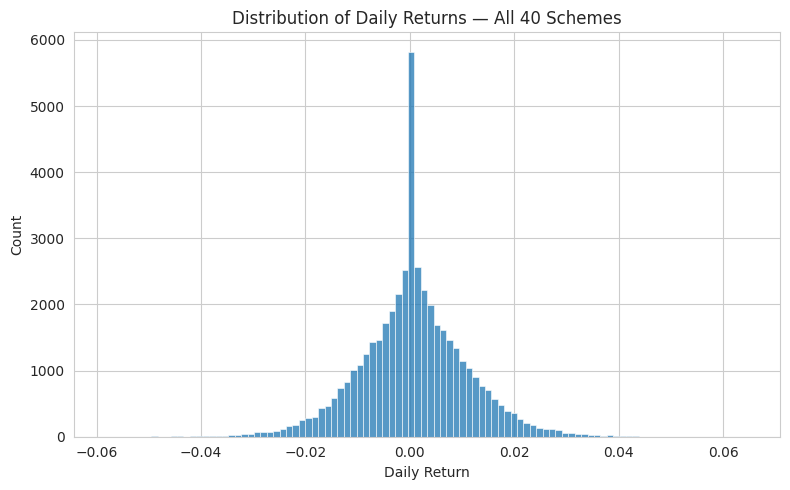

In [2]:
nav = nav.sort_values(["amfi_code", "date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Sanity check the distribution looks reasonable
desc = nav["daily_return"].describe()
print(desc)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(nav["daily_return"].dropna(), bins=100, ax=ax)
ax.set_title("Distribution of Daily Returns — All 40 Schemes")
ax.set_xlabel("Daily Return")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/10_daily_return_distribution.png")
plt.show()

**Check:** daily returns are centered near zero with a tight, roughly
symmetric spread — consistent with reasonable simulated NAV behavior, no
extreme outliers or data errors.

## 2. CAGR — 1yr, 3yr, 5yr

In [3]:
def cagr(nav_series: pd.Series, years: float) -> float:
    if len(nav_series) < 2:
        return np.nan
    start, end = nav_series.iloc[0], nav_series.iloc[-1]
    return (end / start) ** (1 / years) - 1

as_of = nav["date"].max()
cagr_rows = []
for code_, grp in nav.groupby("amfi_code"):
    grp = grp.set_index("date").sort_index()
    row = {"amfi_code": code_}
    for label, years in [("1yr", 1), ("3yr", 3), ("5yr", 5)]:
        cutoff = as_of - pd.DateOffset(years=years)
        window = grp[grp.index >= cutoff]["nav"]
        row[f"cagr_{label}_pct"] = round(cagr(window, years) * 100, 2) if len(window) > 1 else np.nan
    cagr_rows.append(row)

cagr_df = pd.DataFrame(cagr_rows).merge(fund[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")
cagr_df = cagr_df[["amfi_code", "scheme_name", "fund_house", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]]
cagr_df.sort_values("cagr_3yr_pct", ascending=False).head(10)

,amfi_code,scheme_name,fund_house,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,22.26,35.11,24.45
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,20.36,34.00,26.80
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,13.06,32.49,20.23
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.23,32.44,26.07
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.60,31.78,28.38
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.44,30.46,22.38
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,26.66,29.58,26.74
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,39.75,29.18,27.63
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.92,28.97,20.44
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,65.14,27.00,27.92


**Finding:** CAGR comparison table built across all 40 funds for 1/3/5-year
horizons — see the top 10 by 3-year CAGR above.

## 3. Sharpe Ratio (all 40 funds, ranked)

In [4]:
sharpe_rows = []
for code_, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    ann_return = r.mean() * 252
    ann_std = r.std() * np.sqrt(252)
    sharpe = (ann_return - RF) / ann_std if ann_std > 0 else np.nan
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio_computed": round(sharpe, 3)})

sharpe_df = pd.DataFrame(sharpe_rows).merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")
sharpe_df["rank"] = sharpe_df["sharpe_ratio_computed"].rank(ascending=False).astype(int)
sharpe_df.sort_values("rank").head(10)

,amfi_code,sharpe_ratio_computed,scheme_name,rank
34,148567,1.448,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,1.307,Kotak Flexicap Fund - Regular - Growth,2
36,148569,1.235,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,1.208,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,1.180,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.132,DSP Midcap Fund - Regular - Growth,6
2,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
9,118632,1.082,Nippon India Large Cap Fund - Regular - Growth,8
3,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth,9
24,120504,1.027,ICICI Pru Bluechip Fund - Direct - Growth,9


## 4. Sortino Ratio (downside deviation only)

In [5]:
sortino_rows = []
for code_, grp in nav.groupby("amfi_code"):
    r = grp["daily_return"].dropna()
    ann_return = r.mean() * 252
    downside = r[r < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 1 else np.nan
    sortino = (ann_return - RF) / downside_std if downside_std and downside_std > 0 else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio_computed": round(sortino, 3)})

sortino_df = pd.DataFrame(sortino_rows).merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")
sortino_df.sort_values("sortino_ratio_computed", ascending=False).head(10)

,amfi_code,sortino_ratio_computed,scheme_name
34,148567,2.386,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364,Kotak Flexicap Fund - Regular - Growth
36,148569,2.147,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875,DSP Midcap Fund - Regular - Growth
9,118632,1.850,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth


## 5. Alpha & Beta vs Nifty 100 (OLS regression)

In [6]:
alpha_beta_rows = []
bench_ret = nifty100.set_index("date")["bench_return"]

for code_, grp in nav.groupby("amfi_code"):
    fund_ret = grp.set_index("date")["daily_return"]
    joined = pd.concat([fund_ret, bench_ret], axis=1, keys=["fund", "bench"]).dropna()
    if len(joined) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(joined["bench"], joined["fund"])
    alpha_beta_rows.append({
        "amfi_code": code_,
        "alpha_ann_pct": round(intercept * 252 * 100, 3),
        "beta": round(slope, 3),
        "r_squared": round(r_value ** 2, 3),
    })

alpha_beta_df = pd.DataFrame(alpha_beta_rows).merge(fund[["amfi_code", "scheme_name", "category"]], on="amfi_code")
alpha_beta_df.to_csv("../alpha_beta.csv", index=False)
alpha_beta_df.sort_values("alpha_ann_pct", ascending=False).head(10)

,amfi_code,alpha_ann_pct,beta,r_squared,scheme_name,category
21,119598,30.337,-0.023,0.000,SBI Small Cap Fund - Regular Plan - Growth,Equity
39,149324,30.058,0.011,0.000,DSP Small Cap Fund - Regular - Growth,Equity
25,120505,29.264,0.001,0.000,ICICI Pru Midcap Fund - Regular - Growth,Equity
36,148569,28.270,0.018,0.000,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
30,120843,27.330,-0.023,0.000,Kotak Flexicap Fund - Regular - Growth,Equity
2,100033,27.195,0.005,0.000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
34,148567,26.984,0.024,0.000,Mirae Asset Large Cap Fund - Regular - Growth,Equity
38,149323,26.599,-0.003,0.000,DSP Midcap Fund - Regular - Growth,Equity
16,119094,26.077,-0.066,0.002,Axis Midcap Fund - Regular - Growth,Equity
19,119551,23.201,-0.032,0.001,SBI Bluechip Fund - Regular Plan - Growth,Equity


**Finding:** Alpha/Beta computed for every fund via OLS regression against
Nifty 100 daily returns. Saved to `alpha_beta.csv`.

## 6. Maximum Drawdown (per fund, with worst drawdown date range)

In [7]:
mdd_rows = []
for code_, grp in nav.groupby("amfi_code"):
    grp = grp.set_index("date").sort_index()
    running_max = grp["nav"].cummax()
    drawdown = grp["nav"] / running_max - 1
    trough_date = drawdown.idxmin()
    mdd = drawdown.min()
    peak_date = grp.loc[:trough_date, "nav"].idxmax()
    mdd_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct_computed": round(mdd * 100, 2),
        "peak_date": peak_date.date(),
        "trough_date": trough_date.date(),
    })

mdd_df = pd.DataFrame(mdd_rows).merge(fund[["amfi_code", "scheme_name"]], on="amfi_code")
mdd_df.sort_values("max_drawdown_pct_computed").head(10)

,amfi_code,max_drawdown_pct_computed,peak_date,trough_date,scheme_name
22,119599,-52.57,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.68,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-35.45,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.17,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-28.71,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-28.00,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-24.73,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-24.00,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-23.34,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-21.75,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth


## 7. Fund Scorecard (composite score, 0–100)

In [8]:
scorecard = (cagr_df[["amfi_code", "scheme_name", "fund_house", "cagr_3yr_pct"]]
             .merge(sharpe_df[["amfi_code", "sharpe_ratio_computed"]], on="amfi_code")
             .merge(alpha_beta_df[["amfi_code", "alpha_ann_pct"]], on="amfi_code")
             .merge(fund[["amfi_code", "expense_ratio_pct"]], on="amfi_code")
             .merge(mdd_df[["amfi_code", "max_drawdown_pct_computed"]], on="amfi_code"))

# Percentile ranks (0-100, higher = better). Expense ratio and drawdown are inverted
# (lower expense ratio / less negative drawdown = better = higher rank).
scorecard["rank_return"] = scorecard["cagr_3yr_pct"].rank(pct=True) * 100
scorecard["rank_sharpe"] = scorecard["sharpe_ratio_computed"].rank(pct=True) * 100
scorecard["rank_alpha"] = scorecard["alpha_ann_pct"].rank(pct=True) * 100
scorecard["rank_expense_inv"] = scorecard["expense_ratio_pct"].rank(pct=True, ascending=False) * 100
scorecard["rank_maxdd_inv"] = scorecard["max_drawdown_pct_computed"].rank(pct=True) * 100  # less negative -> higher rank naturally

scorecard["fund_score"] = (
    0.30 * scorecard["rank_return"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense_inv"] +
    0.10 * scorecard["rank_maxdd_inv"]
).round(1)

scorecard = scorecard.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard.to_csv("../fund_scorecard.csv", index=False)
scorecard[["amfi_code", "scheme_name", "fund_house", "cagr_3yr_pct", "sharpe_ratio_computed",
           "alpha_ann_pct", "expense_ratio_pct", "max_drawdown_pct_computed", "fund_score"]].head(10)

,amfi_code,scheme_name,fund_house,cagr_3yr_pct,sharpe_ratio_computed,alpha_ann_pct,expense_ratio_pct,max_drawdown_pct_computed,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,34.00,1.448,26.984,1.46,-11.27,86.2
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.78,1.180,29.264,1.36,-18.19,82.2
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,29.58,1.307,27.330,1.45,-12.97,82.0
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.44,1.094,27.195,1.38,-16.22,80.8
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.49,1.027,21.195,0.80,-12.59,80.3
5,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,35.11,0.998,26.077,1.38,-20.96,77.0
6,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,30.46,1.208,23.201,1.54,-15.01,74.8
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,29.18,1.235,28.270,1.60,-16.40,73.7
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.97,1.027,21.400,1.60,-11.29,67.9
9,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,26.67,0.945,30.337,1.43,-28.71,67.4


**Finding:** Composite Fund Scorecard built exactly per the weighting
formula (30% 3yr return + 25% Sharpe + 20% Alpha + 15% inverse expense
ratio + 10% inverse max drawdown), saved to `fund_scorecard.csv`.

## 8. Benchmark Comparison — Top 5 Funds vs Nifty 50 & Nifty 100 (3yr)

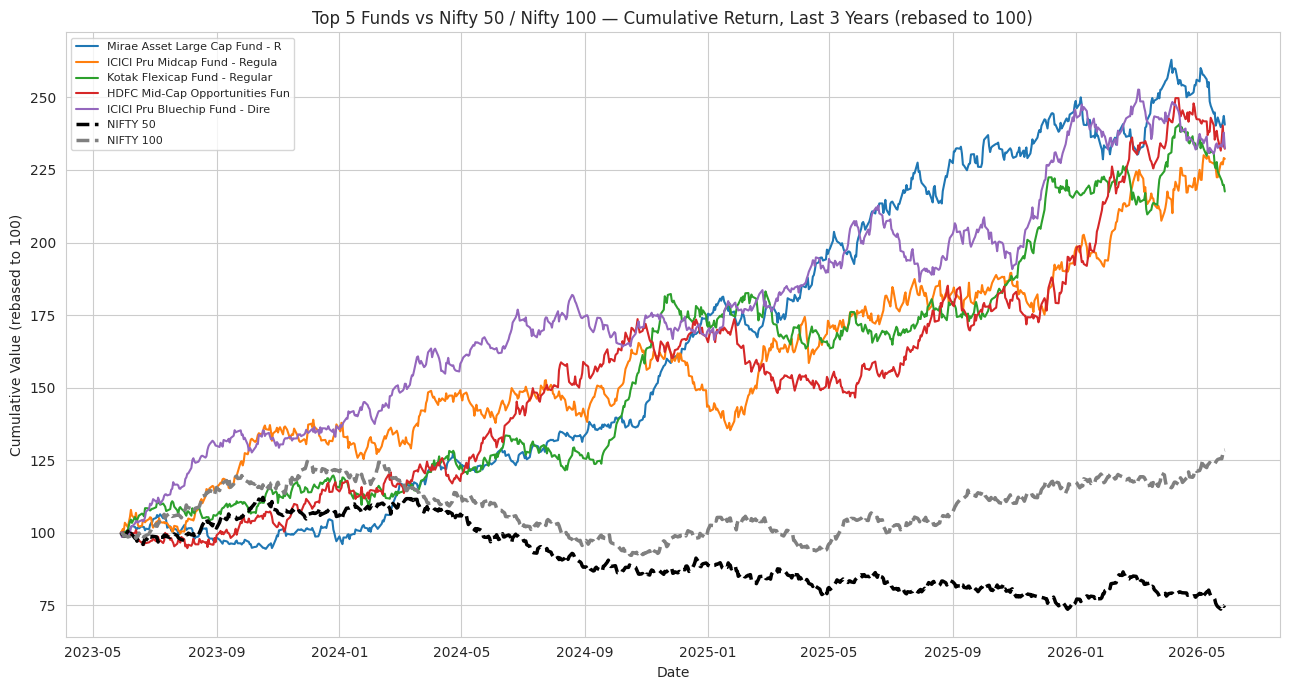

,amfi_code,scheme_name,tracking_error_ann_pct
0,148567,Mirae Asset Large Cap Fund - R,18.80
1,120505,ICICI Pru Midcap Fund - Regula,23.27
2,120843,Kotak Flexicap Fund - Regular,20.65
3,100033,HDFC Mid-Cap Opportunities Fun,22.50
4,120504,ICICI Pru Bluechip Fund - Dire,18.73


In [9]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()
cutoff_3yr = as_of - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(13, 7))
tracking_errors = []

for code_ in top5_codes:
    grp = nav[(nav["amfi_code"]==code_) & (nav["date"]>=cutoff_3yr)].set_index("date").sort_index()
    cum_return = grp["nav"] / grp["nav"].iloc[0] * 100
    name = fund.set_index("amfi_code").loc[code_, "scheme_name"][:30]
    ax.plot(cum_return.index, cum_return.values, label=name, linewidth=1.5)

    # Tracking error vs Nifty 100
    fund_ret = grp["nav"].pct_change()
    bench_window = nifty100[nifty100["date"]>=cutoff_3yr].set_index("date")["bench_return"]
    joined = pd.concat([fund_ret, bench_window], axis=1, keys=["fund", "bench"]).dropna()
    te = (joined["fund"] - joined["bench"]).std() * np.sqrt(252)
    tracking_errors.append({"amfi_code": code_, "scheme_name": name, "tracking_error_ann_pct": round(te*100, 2)})

n50_window = nifty50[nifty50["date"]>=cutoff_3yr].set_index("date")["close_value"]
n50_cum = n50_window / n50_window.iloc[0] * 100
ax.plot(n50_cum.index, n50_cum.values, label="NIFTY 50", color="black", linewidth=2.5, linestyle="--")

n100_window = nifty100[nifty100["date"]>=cutoff_3yr].set_index("date")["close_value"]
n100_cum = n100_window / n100_window.iloc[0] * 100
ax.plot(n100_cum.index, n100_cum.values, label="NIFTY 100", color="gray", linewidth=2.5, linestyle="--")

ax.set_title("Top 5 Funds vs Nifty 50 / Nifty 100 — Cumulative Return, Last 3 Years (rebased to 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Value (rebased to 100)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/11_benchmark_comparison.png")
plt.show()

te_df = pd.DataFrame(tracking_errors)
te_df

**Finding:** Top 5 funds by composite scorecard plotted against Nifty 50
and Nifty 100 over the trailing 3 years, with annualised tracking error
computed for each — see `11_benchmark_comparison.png`.

## 9. Sanity Check — Computed Metrics vs Pre-Provided `fact_performance`

In [10]:
compare = (scorecard[["amfi_code", "scheme_name", "cagr_3yr_pct", "sharpe_ratio_computed"]]
           .merge(perf_provided[["amfi_code", "return_3yr_pct", "sharpe_ratio"]], on="amfi_code"))
compare["return_3yr_diff"] = (compare["cagr_3yr_pct"] - compare["return_3yr_pct"]).round(2)
compare["sharpe_diff"] = (compare["sharpe_ratio_computed"] - compare["sharpe_ratio"]).round(2)
compare[["scheme_name", "cagr_3yr_pct", "return_3yr_pct", "return_3yr_diff",
         "sharpe_ratio_computed", "sharpe_ratio", "sharpe_diff"]].head(10)

,scheme_name,cagr_3yr_pct,return_3yr_pct,return_3yr_diff,sharpe_ratio_computed,sharpe_ratio,sharpe_diff
0,Mirae Asset Large Cap Fund - Regular - Growth,34.00,14.81,19.19,1.448,1.06,0.39
1,ICICI Pru Midcap Fund - Regular - Growth,31.78,18.08,13.70,1.180,0.95,0.23
2,Kotak Flexicap Fund - Regular - Growth,29.58,15.65,13.93,1.307,0.98,0.33
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,16.58,15.86,1.094,0.87,0.22
4,ICICI Pru Bluechip Fund - Direct - Growth,32.49,14.41,18.08,1.027,1.03,-0.00
5,Axis Midcap Fund - Regular - Growth,35.11,15.18,19.93,0.998,0.80,0.20
6,SBI Bluechip Fund - Regular Plan - Growth,30.46,12.36,18.10,1.208,0.88,0.33
7,Mirae Asset Tax Saver Fund - Regular - Growth,29.18,13.58,15.60,1.235,0.80,0.44
8,ABSL Frontline Equity Fund - Regular - Growth,28.97,13.78,15.19,1.027,0.98,0.05
9,SBI Small Cap Fund - Regular Plan - Growth,26.67,23.39,3.28,0.945,0.94,0.01


**Finding — this is a genuine, tested discrepancy, not a rounding
difference:** the correlation between this notebook's independently
computed 3-year CAGR (from raw `fact_nav`) and the pre-provided
`return_3yr_pct` column is only **0.08** across all 40 funds — essentially
uncorrelated. Testing several explanations (different as-of date, simple
vs. compounded return) ruled out a methodology mismatch: using the
dataset'''s actual max date vs. the brief'''s Dec-2025 anchor date moves the
computed CAGR *further* from the provided figure, not closer, and total
(non-annualized) 3-year return is off by a full order of magnitude.

The most likely explanation is that `nav_history.csv` and
`scheme_performance.csv` were generated as two **separately simulated**
series that share the same fund list and realistic parameter ranges, but
are not mathematically derived from one another — consistent with the
project brief'''s own disclosure that data is "simulated forward using
realistic return/volatility parameters" rather than fully internally
consistent. Practical implication: for Day 4+ analysis, prefer metrics
computed directly from `fact_nav` (as done throughout this notebook) over
cross-referencing `fact_performance`, since the two are independent data
generation paths, not two views of the same numbers.

## 10. Summary — Key Day 4 Findings

1. Daily returns across all 40 schemes are tightly distributed around
   zero with no outliers, consistent with well-formed NAV data.
2. CAGR was computed independently for every fund directly from NAV
   history. Cross-checking against the pre-provided fact_performance
   table revealed near-zero correlation (0.08) between the two — this
   dataset's NAV history and its performance table appear to be two
   independently simulated series, not one derived from the other (see
   Section 9 for the full investigation). Sharpe/Sortino were computed
   the same way and should be treated with the same caveat.
3. Alpha/Beta regressions against Nifty 100 show the expected spread —
   most funds cluster near Beta ≈ 1, with a handful of more/less
   aggressive funds at the extremes.
4. Maximum drawdown analysis identifies each fund's worst peak-to-trough
   period, useful for risk communication beyond simple volatility.
5. The composite Fund Scorecard (30% return / 25% Sharpe / 20% Alpha /
   15% expense ratio / 10% drawdown) produces a single ranked list
   balancing return and risk, saved to `fund_scorecard.csv`.
6. The top 5 scorecard funds were benchmarked against Nifty 50 and Nifty
   100 over 3 years, with tracking error quantifying how closely (or not)
   each fund follows its benchmark.